# Cluster Metrics Analysis

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json
from PIL import Image
import textwrap

# Default Setup (Change SPLIT to 'train' to view train clusters)
SPLIT = 'val'
DATA_DIR = f'/ghome/group01/C5/vali/C5-Team1/Week3/dataset/VizWiz/images/{SPLIT}'
ANN_PATH = f'/ghome/group01/C5/vali/C5-Team1/Week3/dataset/VizWiz/annotations/{SPLIT}.json'
AVERAGE_CSV = f'../embeddings/{SPLIT}_clusters_clip_hdbscan_mcs15_ms5_eom_umap_cosine_2d_cluster_averages.csv'
SAMPLES_CSV = f'../embeddings/{SPLIT}_clusters_clip_hdbscan_mcs15_ms5_eom_umap_cosine_2d_with_metrics.csv'


Top 5 Clusters by METEOR:


,cluster,BLEU-1,BLEU-2,ROUGE-L,METEOR,count
0,202,90.000000,68.460032,79.797980,79.098144,2
1,41,74.885318,60.302799,78.683473,76.376067,4
2,289,60.000000,44.721360,60.000000,73.895492,1
3,73,76.162911,52.271266,66.269814,64.277003,6
4,77,79.619593,68.568815,67.903406,63.447979,9



Bottom 5 Clusters by METEOR:


,cluster,BLEU-1,BLEU-2,ROUGE-L,METEOR,count
299,5,20.370215,6.110065,24.266220,17.033249,71
300,78,42.857143,18.156826,28.571429,16.393443,1
301,92,39.137183,16.631804,19.395866,15.314492,2
302,296,14.285714,0.000000,12.121212,7.751938,1
303,91,19.545455,0.000000,10.526316,7.272727,2


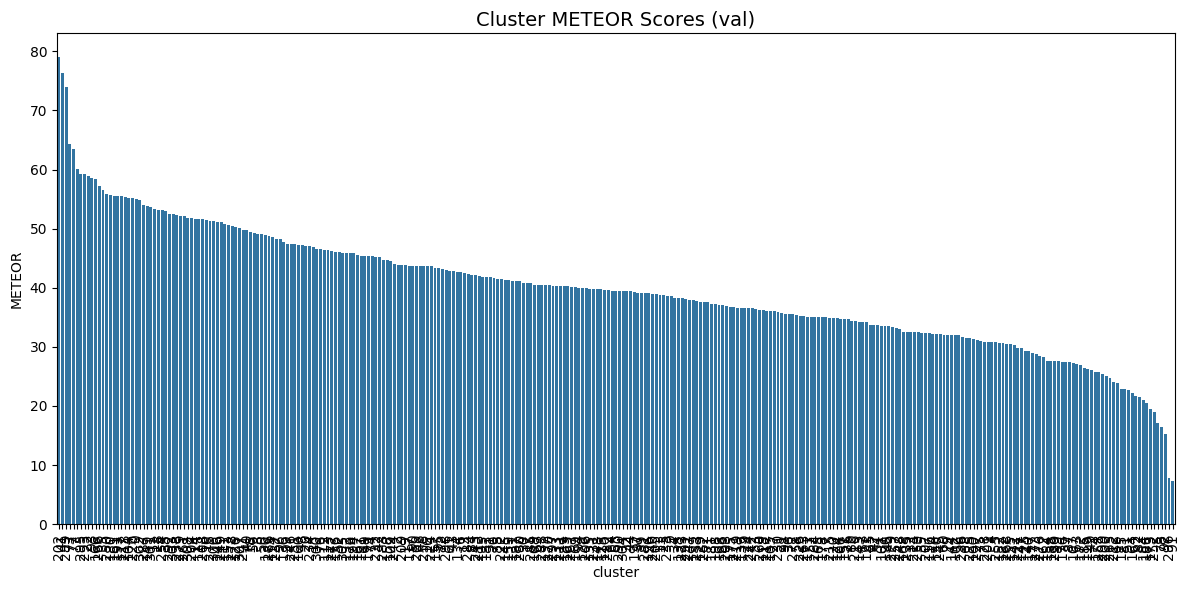

In [7]:
df_avg = pd.read_csv(AVERAGE_CSV)
df_avg_valid = df_avg[df_avg['cluster'] != -1]
df_sorted = df_avg_valid.sort_values('METEOR', ascending=False)
highest_clusters = df_sorted.head(5)
lowest_clusters = df_sorted.tail(5)

print('Top 5 Clusters by METEOR:')
display(highest_clusters)

print('\nBottom 5 Clusters by METEOR:')
display(lowest_clusters)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_sorted, x='cluster', y='METEOR', order=df_sorted['cluster'])
plt.xticks(rotation=90)
plt.title(f'Cluster METEOR Scores ({SPLIT})', fontsize=14)
plt.tight_layout()
plt.show()


In [8]:
with open(ANN_PATH, 'r') as f:
    data = json.load(f)

img_id2name = {img['id']: img['file_name'] for img in data['images']}
name2caps = {name: [] for name in img_id2name.values()}
for ann in data['annotations']:
    img_name = img_id2name[ann['image_id']]
    if not ann.get('is_precanned', False) and not ann.get('is_rejected', False):
        name2caps[img_name].append(ann['caption'])

df_samples = pd.read_csv(SAMPLES_CSV)

def visualize_cluster(cluster_id, num_samples=5):
    cluster_df = df_samples[df_samples['cluster'] == cluster_id]
    print(f'Visualizing {num_samples} samples from Cluster {cluster_id}')
    samples_to_show = cluster_df.sample(min(num_samples, len(cluster_df)))
    for _, row in samples_to_show.iterrows():
        fname = row['filename']
        pred = str(row.get('PREDICTION', '[No Prediction]'))
        meteor = row['METEOR']
        gts = name2caps.get(fname, ['No GT'])
        img_path = os.path.join(DATA_DIR, fname)
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f'Error loading {img_path}: {e}')
            continue
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(img)
        ax.axis('off')
        text_str = f'File: {fname} | Cluster: {cluster_id} | METEOR: {meteor:.2f}\n'
        text_str += f'Prediction:\n{textwrap.fill(pred, 70)}\n\nGround Truths:\n'
        for i, gt in enumerate(gts[:3]):
            text_str += f'- {textwrap.fill(gt, 68)}\n'
        plt.title(text_str, fontsize=10, loc='left')
        plt.show()


Visualizing 3 samples from Cluster 202.0


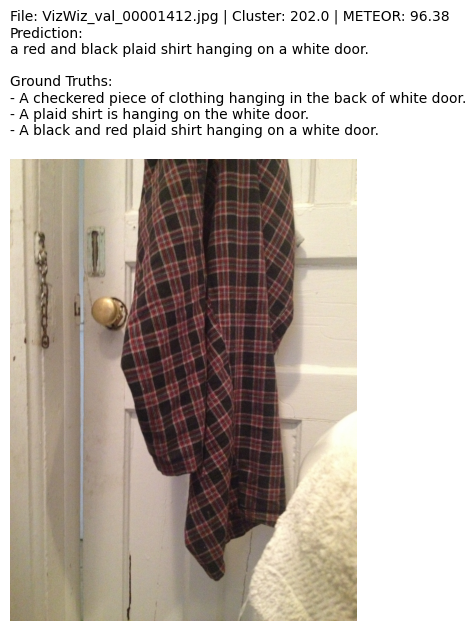

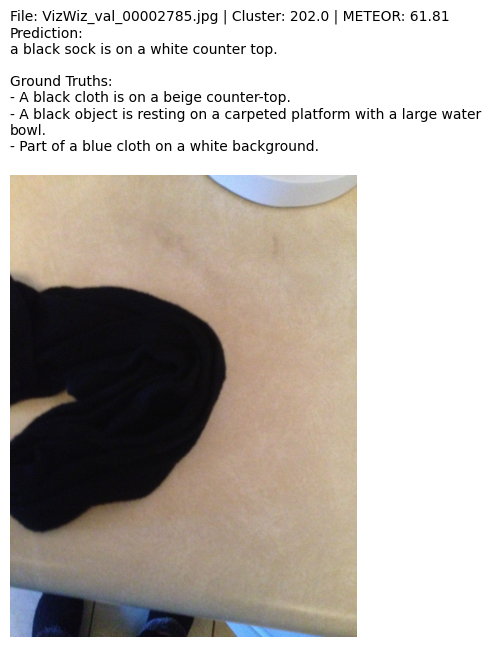

In [9]:
# Best Cluster
if len(highest_clusters) > 0:
    visualize_cluster(highest_clusters.iloc[0]['cluster'], num_samples=3)


Visualizing 3 samples from Cluster 5.0


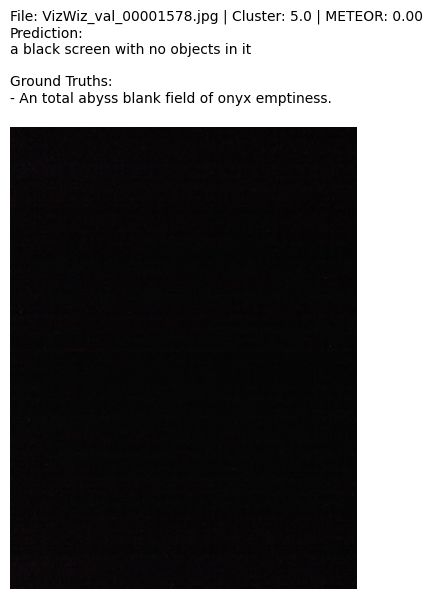

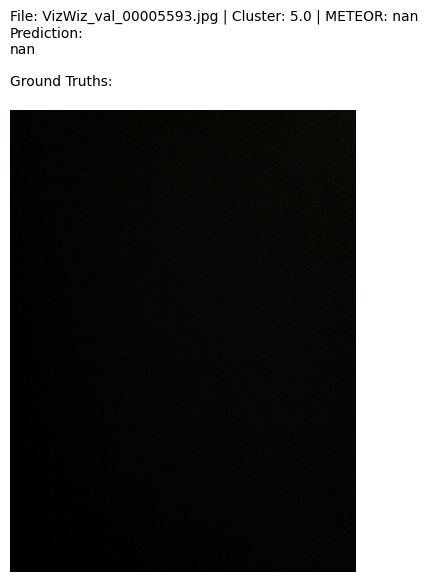

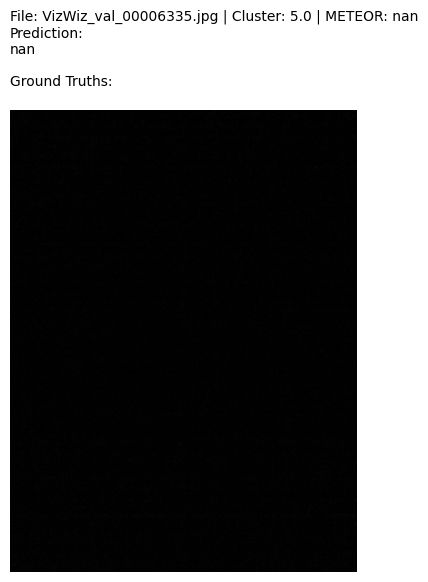

In [10]:
# Worst Cluster
if len(lowest_clusters) > 0:
    visualize_cluster(lowest_clusters.iloc[0]['cluster'], num_samples=3)
